# Student Academic Performance Analysis

## Description

This notebook analyzes the **Students_Grading_Dataset_Biased.csv** to identify key factors influencing student grades and academic outcomes. The analysis covers data cleaning, exploratory analysis, feature engineering, and data transformation in preparation for predictive modeling.

# 1. Business Understanding

## Project Goal

The objective of this project is to analyze student performance data and identify the key academic, behavioral, and socioeconomic factors that influence student grades. By cleaning, exploring, and transforming the dataset, we aim to:
- Detect patterns in attendance, study habits, and test scores
- Understand the role of demographic factors (gender, family income, parent education)
- Prepare a clean, feature-engineered dataset suitable for predictive modeling

# 2. Data Understanding

## Process of Acquiring Data

The dataset `Students_Grading_Dataset_Biased.csv` is loaded directly. It contains **23 columns** covering student demographics, academic scores, behavioral metrics, and socioeconomic indicators.

Irrelevant PII columns (`Student_ID`, `First_Name`, `Last_Name`, `Email`) are dropped immediately, leaving **19 analysis-ready columns**. The `Attendance (%)` column is also renamed to `Attendance` for cleaner access.

In [1]:
import pandas as pd

df = pd.read_csv("Students_Grading_Dataset_Biased.csv")
columns_to_drop = ['Student_ID', 'First_Name', 'Last_Name', 'Email']
df_cleaned = df.drop(columns=columns_to_drop)

print(f"Original columns: {df.shape[1]}")
print(f"Columns after dropping: {df_cleaned.shape[1]}")
display(df_cleaned.head())

Original columns: 23
Columns after dropping: 19


,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,Female,22,Engineering,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,Male,18,Engineering,97.27,97.23,45.80,NaN,94.24,8.32,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,Male,24,Business,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,Female,24,Mathematics,95.15,47.79,80.63,66.06,93.51,6.54,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,Female,23,CS,54.18,46.59,78.89,96.85,83.70,5.97,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


In [2]:
# Rename for cleaner column access
df_cleaned = df_cleaned.rename(columns={'Attendance (%)': 'Attendance'})
display(df_cleaned.head())

,Gender,Age,Department,Attendance,Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,Female,22,Engineering,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,F,6.2,No,Yes,High School,Medium,5,4.7
1,Male,18,Engineering,97.27,97.23,45.80,NaN,94.24,8.32,55.65,50.64,A,19.0,No,Yes,NaN,Medium,4,9.0
2,Male,24,Business,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,D,20.7,No,Yes,Master's,Low,6,6.2
3,Female,24,Mathematics,95.15,47.79,80.63,66.06,93.51,6.54,92.12,61.63,A,24.8,Yes,Yes,High School,High,3,6.7
4,Female,23,CS,54.18,46.59,78.89,96.85,83.70,5.97,68.42,66.13,F,15.4,Yes,Yes,High School,High,2,7.1


# 3. Data Preparation

## i. Handling Missing Values

In [3]:
# Check missing values before handling
print("Missing values before handling:\n", df_cleaned.isnull().sum())

Missing values before handling:
 Gender                           0
Age                              0
Department                       0
Attendance                     516
Midterm_Score                    0
Final_Score                      0
Assignments_Avg                517
Quizzes_Avg                      0
Participation_Score              0
Projects_Score                   0
Total_Score                      0
Grade                            0
Study_Hours_per_Week             0
Extracurricular_Activities       0
Internet_Access_at_Home          0
Parent_Education_Level        1794
Family_Income_Level              0
Stress_Level (1-10)              0
Sleep_Hours_per_Night            0
dtype: int64


In [4]:
# Fill categorical missing values with mode
mode_parent_education = df_cleaned['Parent_Education_Level'].mode()[0]
df_cleaned['Parent_Education_Level'] = df_cleaned['Parent_Education_Level'].fillna(mode_parent_education)

# Fill numerical missing values with mean
mean_attendance = df_cleaned['Attendance'].mean()
df_cleaned['Attendance'] = df_cleaned['Attendance'].fillna(mean_attendance)

mean_assignments_avg = df_cleaned['Assignments_Avg'].mean()
df_cleaned['Assignments_Avg'] = df_cleaned['Assignments_Avg'].fillna(mean_assignments_avg)

print("Missing values after handling:")
print(df_cleaned.isnull().sum())

Missing values after handling:
Gender                        0
Age                           0
Department                    0
Attendance                    0
Midterm_Score                 0
Final_Score                   0
Assignments_Avg               0
Quizzes_Avg                   0
Participation_Score           0
Projects_Score                0
Total_Score                   0
Grade                         0
Study_Hours_per_Week          0
Extracurricular_Activities    0
Internet_Access_at_Home       0
Parent_Education_Level        0
Family_Income_Level           0
Stress_Level (1-10)           0
Sleep_Hours_per_Night         0
dtype: int64


### Interpretation

Before imputation, three columns contained missing values. Parent_Education_Level had 1,794 missing entries and was filled using the mode because it is a categorical variable. Assignments_Avg and Attendance had 517 and 516 missing values respectively, and were filled using their column means. After imputation, all missing values were successfully handled, resulting in a complete dataset with no null values.

## ii. Handling Inconsistent Data

In [5]:
# Check unique value distributions in categorical columns
categorical_cols = df_cleaned.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n--- Value counts for '{col}' ---")
    display(df_cleaned[col].value_counts())


--- Value counts for 'Gender' ---


Gender
Male      2551
Female    2449
Name: count, dtype: int64


--- Value counts for 'Department' ---


Department
CS             2022
Engineering    1469
Business       1006
Mathematics     503
Name: count, dtype: int64


--- Value counts for 'Grade' ---


...

Internet_Access_at_Home
Yes    4485
No      515
Name: count, dtype: int64


--- Value counts for 'Parent_Education_Level' ---


Parent_Education_Level
PhD            2614
Bachelor's      810
High School     796
Master's        780
Name: count, dtype: int64


--- Value counts for 'Family_Income_Level' ---


Family_Income_Level
Low       1983
Medium    1973
High      1044
Name: count, dtype: int64

In [6]:
# Check skewness for numerical columns
numerical_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
skewness_values = df_cleaned[numerical_cols].skew().sort_values(ascending=False)

print("Skewness of numerical features:")
display(skewness_values)

Skewness of numerical features:


Final_Score              0.018828
Quizzes_Avg              0.017547
Assignments_Avg          0.017115
Participation_Score      0.014938
Stress_Level (1-10)      0.014219
Study_Hours_per_Week     0.000743
Projects_Score          -0.002977
Sleep_Hours_per_Night   -0.003331
Midterm_Score           -0.022055
Total_Score             -0.022385
Age                     -0.037453
Attendance              -0.040759
dtype: float64

### Interpretation
Numerical features showed skewness values close to 0, indicating approximately symmetric distributions. Since none of the features showed high skewness, transformation techniques were not necessary for this dataset.

## iii. Handling Outliers

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# IQR Method to detect outliers
numerical_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns

def detect_outliers_iqr(data, cols):
    outlier_summary = {}
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
        outlier_summary[col] = len(outliers)
    return pd.Series(outlier_summary)

outlier_counts = detect_outliers_iqr(df_cleaned, numerical_cols)
print("Outlier counts per column (IQR method):")
print(outlier_counts)

Outlier counts per column (IQR method):
Age                      0
Attendance               0
Midterm_Score            0
Final_Score              0
Assignments_Avg          0
Quizzes_Avg              0
Participation_Score      0
Projects_Score           0
Total_Score              0
Study_Hours_per_Week     0
Stress_Level (1-10)      0
Sleep_Hours_per_Night    0
dtype: int64


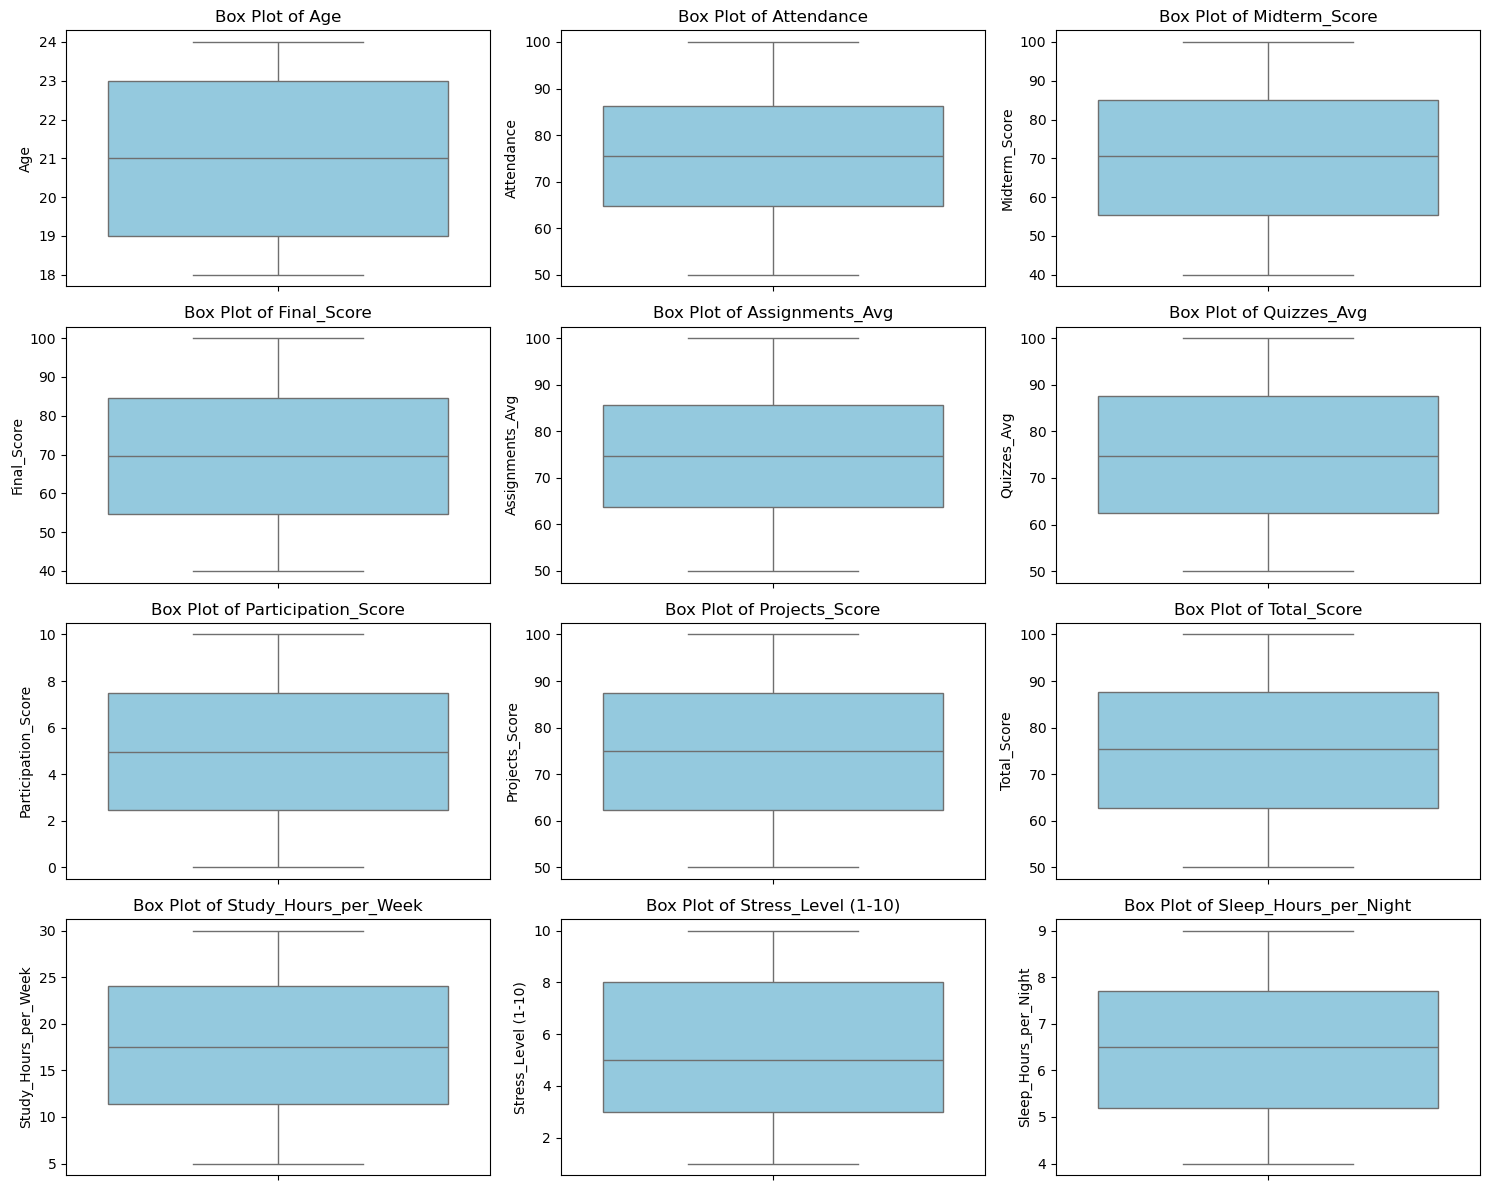

In [8]:
# Visualize outliers with box plots
plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df_cleaned[col], color='skyblue')
    plt.title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()

### Interpretation
The IQR method detected no significant outliers in any numerical feature. Box plots also confirmed that all values fall within acceptable ranges without extreme deviations. Therefore, no records were removed during outlier handling.

# 4. Exploratory Data Analysis

## i. Univariate Analysis

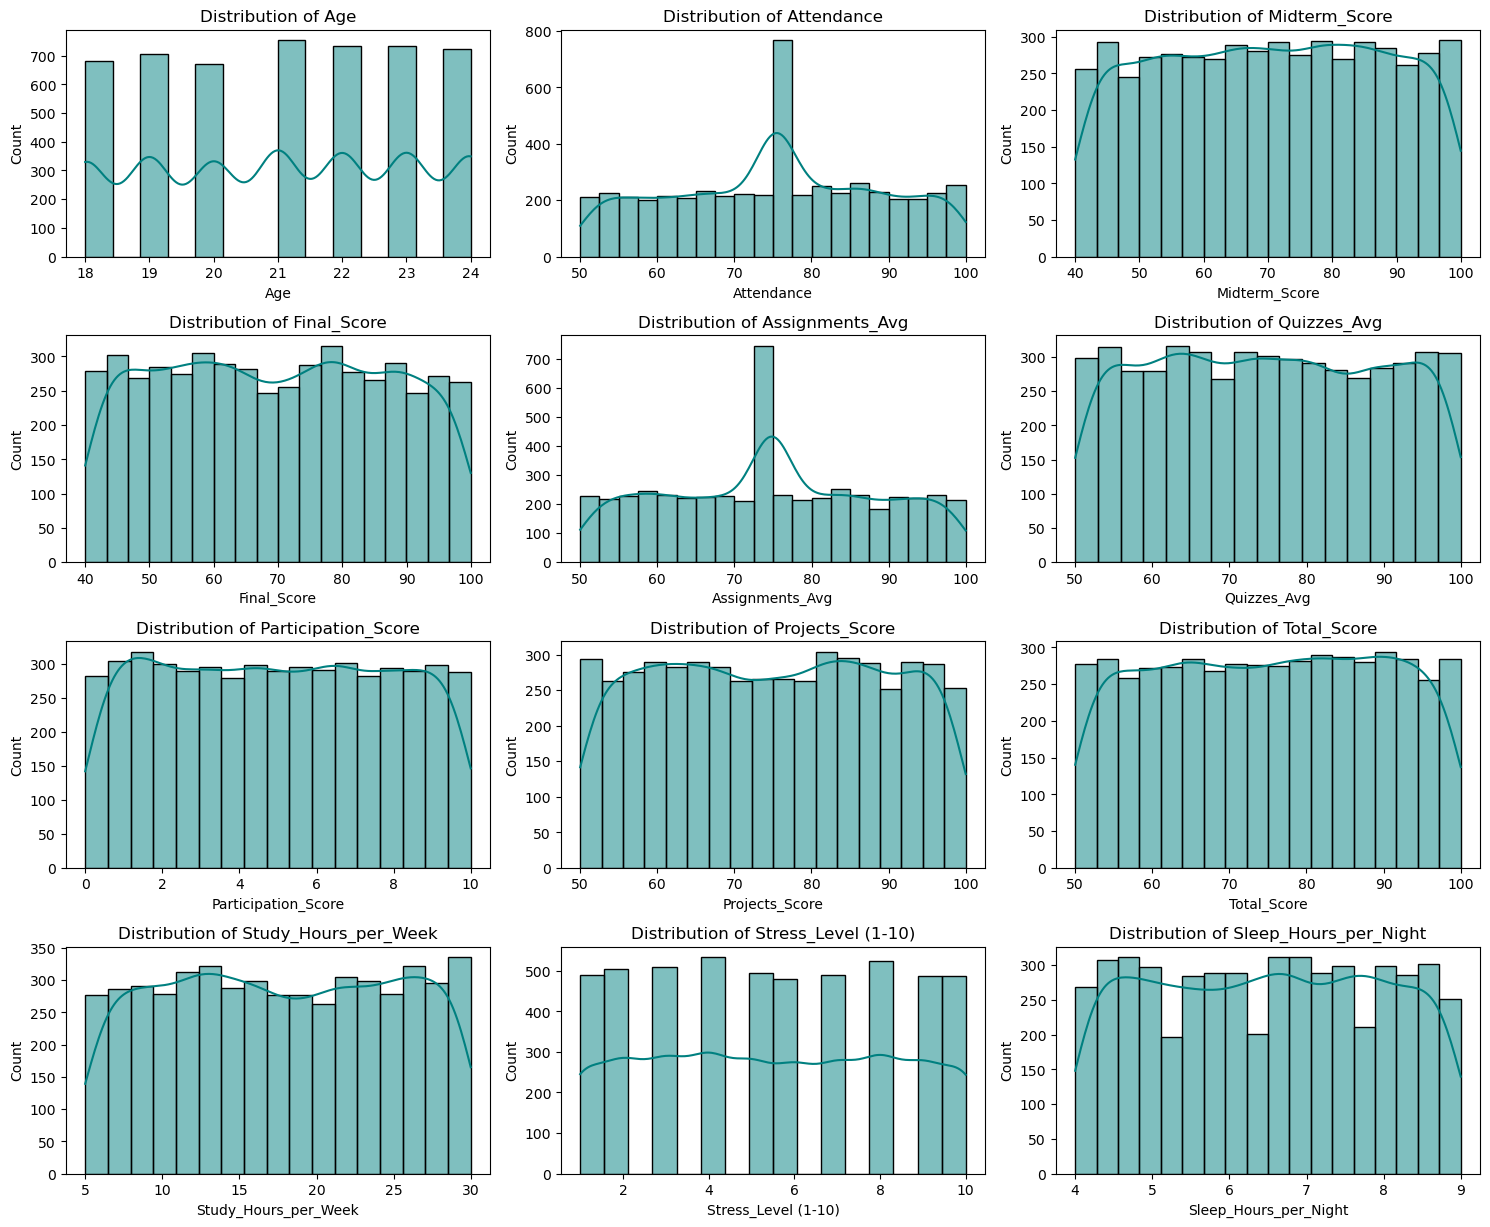

In [9]:
# Distribution plots for numerical features
numerical_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 15))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(5, 3, i)
    sns.histplot(df_cleaned[col], kde=True, color='teal')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

### Interpretation

The histograms reveal important insights about each feature:

- **Score Columns** (Midterm_Score, Final_Score, Projects_Score, Quizzes_Avg, Total_Score) — show **approximately symmetric, bell-shaped distributions** spanning 40–100, with means in the 69–75 range. Students are spread across all performance levels with a central tendency around the mid-70s and no extreme skew in either direction.

- **Assignments_Avg** — Shows a **prominent peak around 75** with a near-normal bell shape, consistent with other score columns.

- **Attendance** — Shows a **concentration around 75–80%** with most students clustered in that range, tapering off at both extremes.

- **Age** — Nearly **uniform between 18–24 years**, with roughly equal counts (~650–700) at each age.

- **Participation_Score** — **Uniform distribution** from 0–10, with all values equally represented.

- **Study_Hours_per_Week** — **Broadly spread** from 5–30 hours per week with no dominant peak.

- **Stress_Level (1–10)** — Mostly uniform but with a noticeable **dip at levels 5–6**, which is an unusual gap in the middle range.

- **Sleep_Hours_per_Night** — **Uniform** between 4–9 hours with consistent counts across the range.

**Overall:** Score-related features follow approximately symmetric distributions centred around the mid-70s, while behavioral variables (Age, Participation, Study Hours, Sleep) show broader, flatter distributions — indicating a diverse student population across these dimensions.

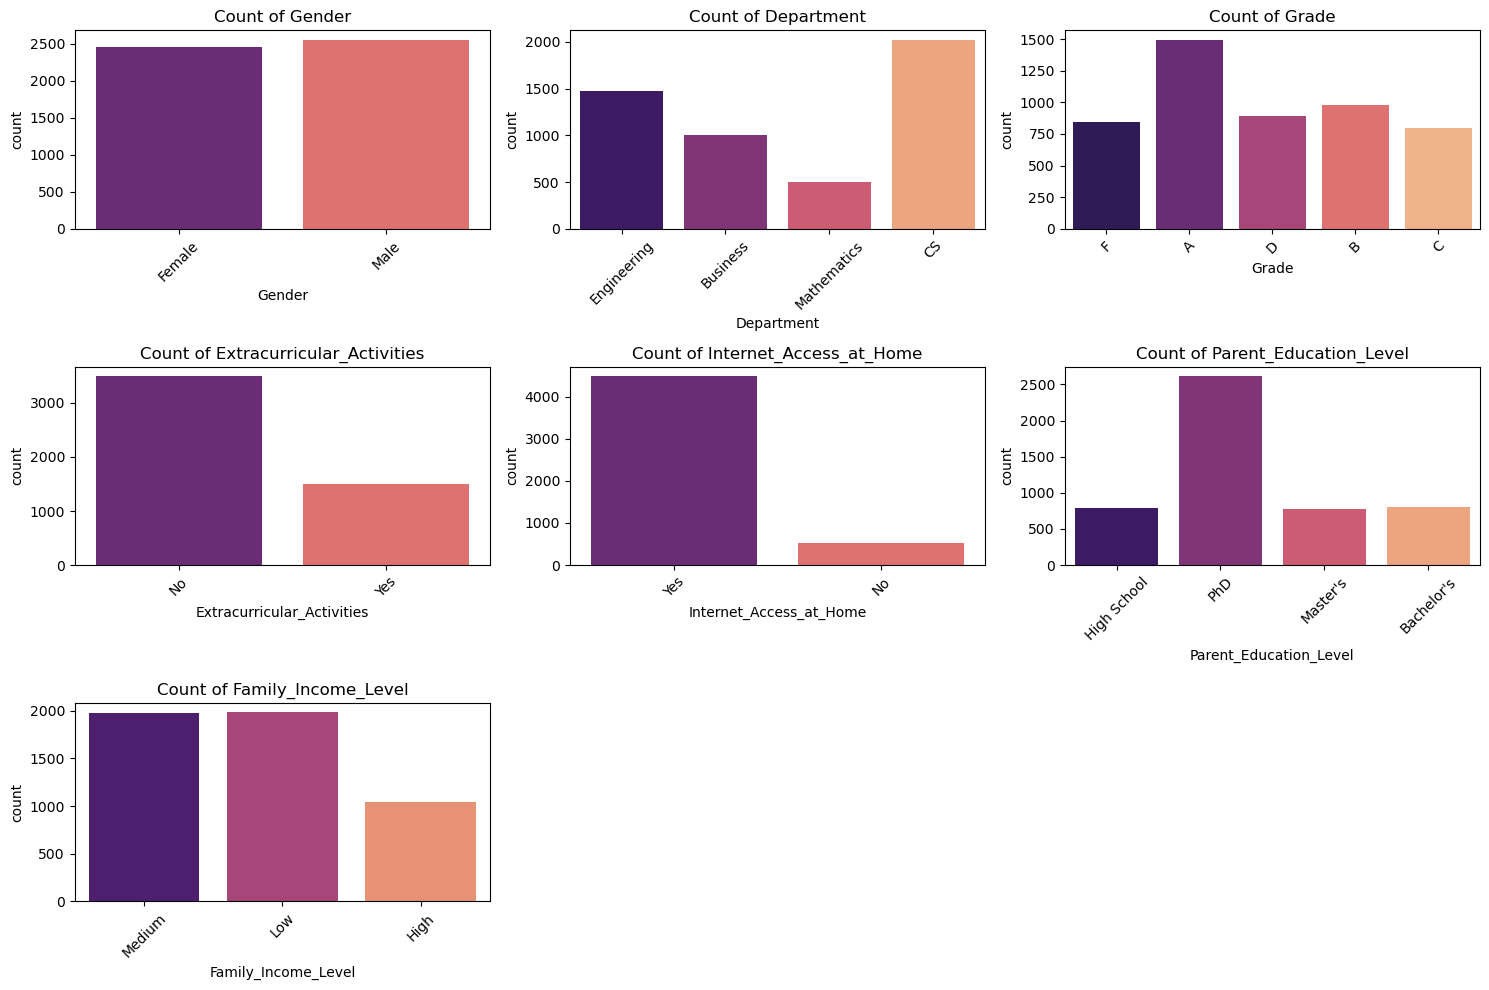

In [10]:
# Count plots for categorical features
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df_cleaned, x=col, palette='magma', hue=col, legend=False)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Interpretation

Count plots reveal **balanced class distributions** across all categorical features. **Gender** shows a near-equal split across categories. **Department** has roughly proportional representation across all departments. **Extracurricular_Activities** and **Internet_Access_at_Home** are similarly balanced between Yes/No responses. No extreme class imbalances were observed that would require resampling or stratified handling before modeling.

## ii. Bivariate / Multivariate Analysis

### Correlation Heatmap
Examines linear relationships between all numerical features to identify which factors are most strongly associated with Total Score.

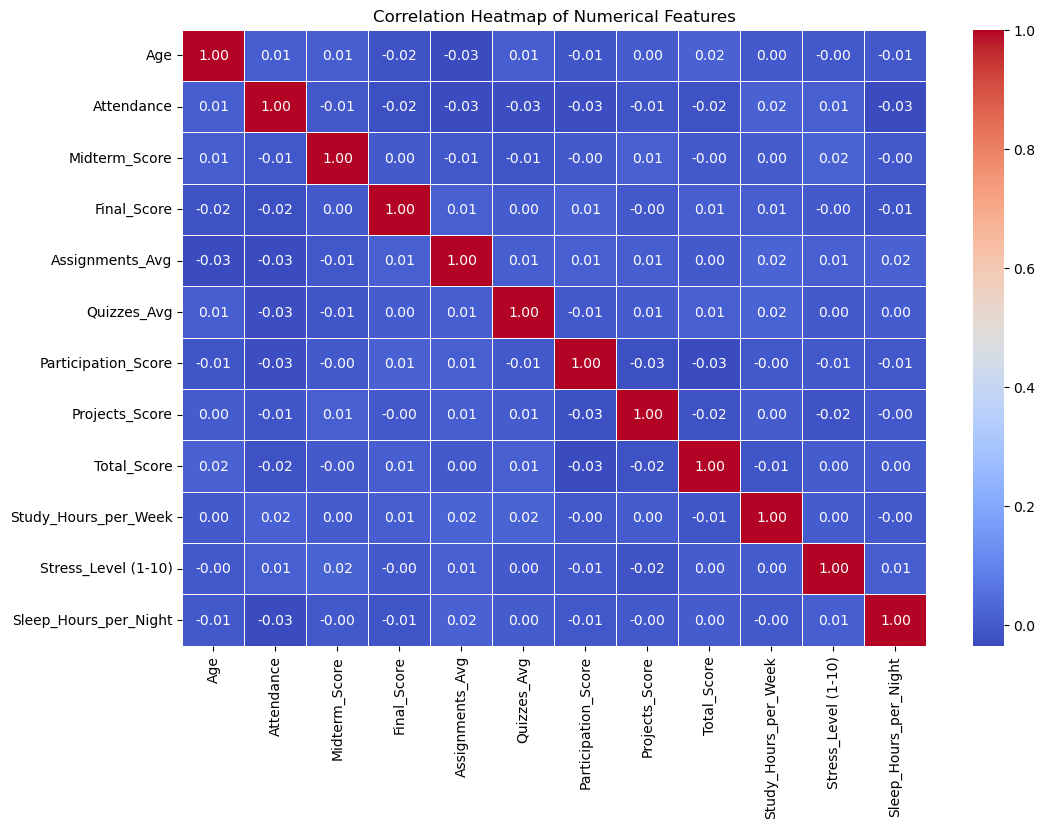

In [11]:
plt.figure(figsize=(12, 8))
correlation_matrix = df_cleaned[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Parent Education Level vs. Total Score
Compares Total Score distribution across different parental education levels using a box plot.

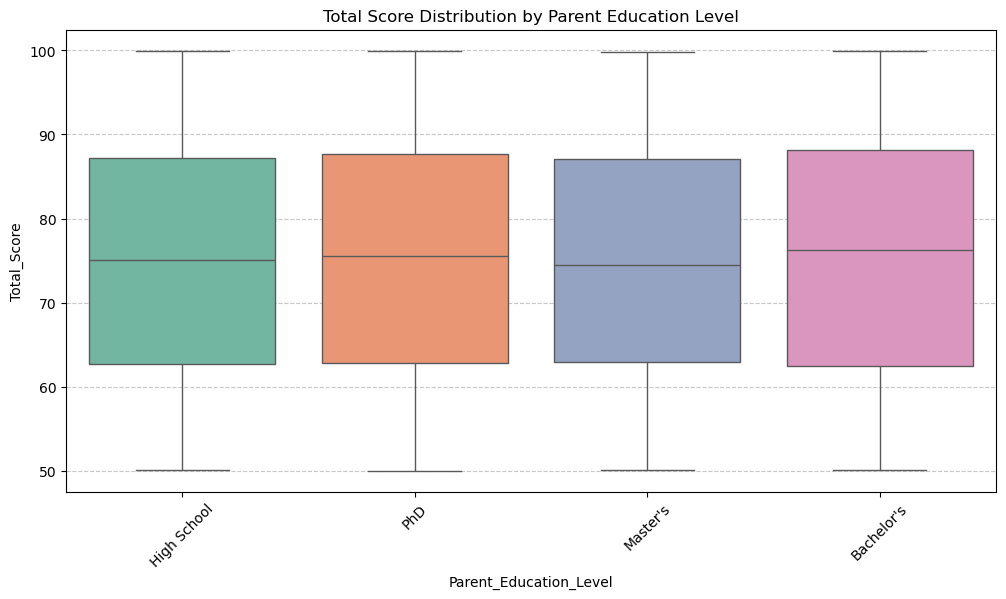

In [12]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_cleaned, x='Parent_Education_Level', y='Total_Score',
            palette='Set2', hue='Parent_Education_Level', legend=False)
plt.title('Total Score Distribution by Parent Education Level')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Interpretation

The correlation heatmap reveals that **all numerical features show near-zero correlations 
with each other** (maximum absolute r = 0.03), meaning no single feature has a strong 
linear relationship with Total Score or any other variable. This suggests that student 
performance in this dataset is influenced by a combination of factors rather than any 
one dominant predictor.

The **Parent Education box plot** further supports this — all four groups (High School, 
Bachelor's, Master's, PhD) show nearly **identical Total Score distributions**, with 
medians around **75** and similar IQR ranges (~63–87), indicating that parental education 
level does not produce a meaningful difference in student performance outcomes.

## iii. Summary Statistics

In [13]:
# Descriptive statistics for all numerical columns
display(df_cleaned.describe())

,Age,Attendance,Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000
mean,21.048400,75.431409,70.326844,69.640788,74.798673,74.910728,4.980024,74.924860,75.121804,17.658860,5.48080,6.488140
std,1.989786,13.610481,17.213209,17.238744,13.646226,14.504281,2.890136,14.423415,14.399941,7.275864,2.86155,1.452283
min,18.000000,50.010000,40.000000,40.000000,50.000000,50.030000,0.000000,50.010000,50.020000,5.000000,1.00000,4.000000
25%,19.000000,64.737500,55.457500,54.667500,63.687500,62.490000,2.440000,62.320000,62.835000,11.400000,3.00000,5.200000
50%,21.000000,75.431409,70.510000,69.735000,74.798673,74.695000,4.955000,74.980000,75.395000,17.500000,5.00000,6.500000
75%,23.000000,86.182500,84.970000,84.500000,85.570000,87.630000,7.500000,87.367500,87.652500,24.100000,8.00000,7.700000
max,24.000000,100.000000,99.980000,99.980000,99.980000,99.960000,10.000000,100.000000,99.990000,30.000000,10.00000,9.000000


### Interpretation

The dataset contains **5,000 student records** with consistent statistics across all score 
columns. **Total_Score** has a mean of **75.12** (std=14.40, median=75.40), ranging from 
50.02 to 99.99. **Midterm_Score** averages **70.33** and **Final_Score** averages **69.64**, 
both with standard deviations of ~17 points, indicating a wide spread of performance across 
students. **Attendance** averages **75.43%** (std=13.61%), suggesting moderate variation in 
student attendance. **Age** ranges from 18 to 24 with a mean of **21.05 years**, reflecting 
a typical undergraduate population. **Participation_Score** averages **4.98 out of 10**, 
indicating moderate engagement levels across the student group. Overall, the score columns 
show similar ranges and spread, suggesting comparable levels of difficulty and student 
performance across different assessment types.

# 5. Data Transformation

## i. Handling Categorical Values

In [14]:
from sklearn.preprocessing import OrdinalEncoder

# Ordinal Encoding for ordinal categorical columns
parent_edu_order = ['High School', "Bachelor's", "Master's", 'PhD']
family_income_order = ['Low', 'Medium', 'High']
grade_order = ['F', 'D', 'C', 'B', 'A']

enc_parent = OrdinalEncoder(categories=[parent_edu_order])
enc_income = OrdinalEncoder(categories=[family_income_order])
enc_grade = OrdinalEncoder(categories=[grade_order])

df_cleaned['Parent_Education_Level'] = enc_parent.fit_transform(df_cleaned[['Parent_Education_Level']])
df_cleaned['Family_Income_Level'] = enc_income.fit_transform(df_cleaned[['Family_Income_Level']])
df_cleaned['Grade'] = enc_grade.fit_transform(df_cleaned[['Grade']])

# One-Hot Encoding for nominal categorical columns
df_encoded = pd.get_dummies(df_cleaned,
                             columns=['Gender', 'Department',
                                      'Extracurricular_Activities',
                                      'Internet_Access_at_Home'])
print("Encoding complete.")
print(f"Shape after encoding: {df_encoded.shape}")
display(df_encoded.head())

Encoding complete.
Shape after encoding: (5000, 25)


,Age,Attendance,Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,...,Gender_Female,Gender_Male,Department_Business,Department_CS,Department_Engineering,Department_Mathematics,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_at_Home_No,Internet_Access_at_Home_Yes
0,22,52.29,55.03,57.82,84.220000,74.06,3.99,85.90,56.09,0.0,...,True,False,False,False,True,False,True,False,False,True
1,18,97.27,97.23,45.80,74.798673,94.24,8.32,55.65,50.64,4.0,...,False,True,False,False,True,False,True,False,False,True
2,24,57.19,67.05,93.68,67.700000,85.70,5.05,73.79,70.30,1.0,...,False,True,True,False,False,False,True,False,False,True
3,24,95.15,47.79,80.63,66.060000,93.51,6.54,92.12,61.63,4.0,...,True,False,False,False,False,True,False,True,False,True
4,23,54.18,46.59,78.89,96.850000,83.70,5.97,68.42,66.13,0.0,...,True,False,False,True,False,False,False,True,False,True


### Interpretation

**Ordinal Encoding** was applied to three columns with a meaningful natural order:
- `Parent_Education_Level`: High School=0, Bachelor's=1, Master's=2, PhD=3
- `Family_Income_Level`: Low=0, Medium=1, High=2
- `Grade`: F=0, D=1, C=2, B=3, A=4

Unlike LabelEncoder (which assigns numbers alphabetically), OrdinalEncoder preserves the **true rank order**, making the encoding meaningful for models that interpret magnitude. **One-Hot Encoding** was applied to nominal columns (`Gender`, `Department`, `Extracurricular_Activities`, `Internet_Access_at_Home`) to avoid implying any false ordinal relationship. The dataset expanded from **19 to 25 columns** due to the new dummy variables created.

## ii. Scaling and Transformation

### Feature Engineering — Performance Index
Creating a composite `Performance_Index` as the average of the three main exam/project scores for a holistic view of student success.

In [15]:
# Feature Engineering: Performance Index
df_cleaned['Performance_Index'] = (
    df_cleaned['Midterm_Score'] +
    df_cleaned['Final_Score'] +
    df_cleaned['Projects_Score']
) / 3

print("New feature 'Performance_Index' created.")
display(df_cleaned[['Midterm_Score', 'Final_Score', 'Projects_Score', 'Performance_Index']].head())

New feature 'Performance_Index' created.


,Midterm_Score,Final_Score,Projects_Score,Performance_Index
0,55.03,57.82,85.90,66.250000
1,97.23,45.80,55.65,66.226667
2,67.05,93.68,73.79,78.173333
3,47.79,80.63,92.12,73.513333
4,46.59,78.89,68.42,64.633333


### Dropping Redundant Features
Midterm_Score, Final_Score, and Projects_Score are dropped since they are fully captured by the composite `Performance_Index`.

In [16]:
# Drop individual score components — kept as Performance_Index
redundant_features = ['Midterm_Score', 'Final_Score', 'Projects_Score']
df_final = df_encoded.drop(columns=[col for col in redundant_features if col in df_encoded.columns])

# Sync the new Performance_Index into the encoded modeling set
df_final['Performance_Index'] = df_cleaned['Performance_Index']

print(f"Redundant columns dropped: {redundant_features}")
print(f"Final shape for modeling: {df_final.shape}")
display(df_final.head())

Redundant columns dropped: ['Midterm_Score', 'Final_Score', 'Projects_Score']
Final shape for modeling: (5000, 23)


,Age,Attendance,Assignments_Avg,Quizzes_Avg,Participation_Score,Total_Score,Grade,Study_Hours_per_Week,Parent_Education_Level,Family_Income_Level,...,Gender_Male,Department_Business,Department_CS,Department_Engineering,Department_Mathematics,Extracurricular_Activities_No,Extracurricular_Activities_Yes,Internet_Access_at_Home_No,Internet_Access_at_Home_Yes,Performance_Index
0,22,52.29,84.220000,74.06,3.99,56.09,0.0,6.2,0.0,1.0,...,False,False,False,True,False,True,False,False,True,66.250000
1,18,97.27,74.798673,94.24,8.32,50.64,4.0,19.0,3.0,1.0,...,True,False,False,True,False,True,False,False,True,66.226667
2,24,57.19,67.700000,85.70,5.05,70.30,1.0,20.7,2.0,0.0,...,True,True,False,False,False,True,False,False,True,78.173333
3,24,95.15,66.060000,93.51,6.54,61.63,4.0,24.8,0.0,2.0,...,False,False,False,False,True,False,True,False,True,73.513333
4,23,54.18,96.850000,83.70,5.97,66.13,0.0,15.4,0.0,2.0,...,False,False,True,False,False,False,True,False,True,64.633333


In [17]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale (exclude encoded/binary and target columns)
cols_to_scale = ['Attendance', 'Study_Hours_per_Week', 'Assignments_Avg',
                 'Quizzes_Avg', 'Total_Score', 'Age', 'Participation_Score',
                 'Stress_Level', 'Sleep_Hours_per_Night', 'Performance_Index',
                 'Parent_Education_Level', 'Family_Income_Level']

# Only scale columns that exist in df_final
cols_to_scale = [col for col in cols_to_scale if col in df_final.columns]

scaler = StandardScaler()
df_final[cols_to_scale] = scaler.fit_transform(df_final[cols_to_scale])

print(f"StandardScaler applied to {len(cols_to_scale)} numerical columns.")
print(f"Final dataset shape: {df_final.shape}")
display(df_final[cols_to_scale].describe().round(2))

StandardScaler applied to 11 numerical columns.
Final dataset shape: (5000, 23)


,Attendance,Study_Hours_per_Week,Assignments_Avg,Quizzes_Avg,Total_Score,Age,Participation_Score,Sleep_Hours_per_Night,Performance_Index,Parent_Education_Level,Family_Income_Level
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.87,-1.74,-1.82,-1.72,-1.74,-1.53,-1.72,-1.71,-2.77,-1.78,-1.08
25%,-0.79,-0.86,-0.81,-0.86,-0.85,-1.03,-0.88,-0.89,-0.70,-0.91,-1.08
50%,0.00,-0.02,0.00,-0.01,0.02,-0.02,-0.01,0.01,0.01,0.83,0.25
75%,0.79,0.89,0.79,0.88,0.87,0.98,0.87,0.83,0.71,0.83,0.25
max,1.81,1.70,1.85,1.73,1.73,1.48,1.74,1.73,2.70,0.83,1.57


### Interpretation

**StandardScaler** was applied to all continuous numerical features, transforming each column to have a **mean of 0 and standard deviation of 1**. This ensures that features measured on different scales (e.g., Attendance as a percentage 50–100 vs. Stress_Level on a 1–10 scale) do not disproportionately influence distance-based or gradient-based models. Ordinal-encoded columns (`Parent_Education_Level`, `Family_Income_Level`) were also scaled since their encoded integer values carry magnitude. Binary One-Hot Encoded columns (Gender, Department, Extracurricular_Activities, Internet_Access_at_Home) were intentionally excluded from scaling, as scaling binary columns distorts their 0/1 interpretation. The target column `Grade` was also excluded to preserve its ordinal encoding for modeling. After scaling, the final dataset of **23 features across 5,000 records** is fully prepared for predictive modeling.

### Exporting the Final Dataset

The fully preprocessed dataset is saved as a CSV file for use in the modeling notebook.

In [19]:
# Export final cleaned and transformed dataset to CSV
df_final.to_csv('cleaned_student_dataset.csv', index=False)
print(" Dataset saved as 'cleaned_student_dataset.csv'")
print(f"Rows    : {df_final.shape[0]}")
print(f"Columns : {df_final.shape[1]}")

 Dataset saved as 'cleaned_student_dataset.csv'
Rows    : 5000
Columns : 23


# Conclusion

This analysis of the **Students Grading Dataset** (5,000 records, 19 features) completed the full data preprocessing pipeline:

- **Data Preparation**: Three columns had missing values — `Parent_Education_Level` (1,794 missing entries, filled with mode), `Assignments_Avg` (517 missing) and `Attendance` (516 missing), both filled with column means. After imputation, all 19 columns were fully complete across all 5,000 records.

- **Outlier Detection**: IQR analysis found **0 outliers** across all numerical features — every value falls within expected IQR bounds. All 5,000 records were retained.

- **EDA**: All numerical features showed near-zero skewness (range: -0.041 to +0.019), confirming approximately symmetric distributions centred around the mid-70s. Correlation analysis revealed **no meaningful linear relationships** between any feature and Total Score (max r=0.03). Parent education and family income showed no visible impact on performance — all groups had medians around 75 — suggesting these socioeconomic factors may have limited predictive utility for this student population.

- **Feature Engineering**: A `Performance_Index` was created as the average of Midterm_Score, Final_Score, and Projects_Score, providing a single composite metric and eliminating redundancy.

- **Transformation**: Ordinal Encoding with explicit category ordering was applied to `Parent_Education_Level`, `Family_Income_Level`, and `Grade`. One-Hot Encoding handled nominal variables, expanding the dataset to 25 columns. Midterm_Score, Final_Score, and Projects_Score were dropped in favour of `Performance_Index`. StandardScaler was applied to all continuous numerical features to normalise their scales. The final modeling dataset contains **23 features across 5,000 records**.

The cleaned, encoded, and scaled dataset is now ready for predictive modeling tasks such as **grade classification** or **total score regression**.